모델 학습

✅ Font setup for Linux complete.
🚀 Using device: cuda
✅ Train shape: (1999, 2), Test shape: (500, 2)
✅ 51개의 라벨 발견: ['감사', '동아리_구성원', '동아리_네트워크', '동아리_분위기', '동아리_소개', '동아리_역사', '동아리_혜택', '동아리_활동', '면접팁_AI', '면접팁_공통', '면접팁_기획', '면접팁_디자인', '면접팁_백엔드', '면접팁_프론트엔드', '모집_기간', '모집_대상', '모집_인원', '모집_인재상', '배우는_기술', '선발_기준', '선발_일정', '세션_참여조건', '수료_조건', '외부_활동', '운영_방식', '이스터에그', '인사', '졸업후_활동', '지원_방법', '지원_자격', '지원서_작성팁_AI', '지원서_작성팁_공통', '지원서_작성팁_기획', '지원서_작성팁_디자인', '지원서_작성팁_백엔드', '지원서_작성팁_프론트엔드', '초보자_가능', '커리큘럼_형식', '파트_AI', '파트_기획', '파트_디자인', '파트_백엔드', '파트_선택', '파트_프론트엔드', '활동_기간', '활동_빈до', '활동_빈도', '활동_성과', '활동_시간부담', '활동_장소', '회비_안내']


Map: 100%|██████████| 500/500 [00:00<00:00, 63087.42 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🚀 KLUE-BERT 모델 학습을 시작합니다...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,2.552415,0.594000,0.569082
2,No log,1.352017,0.810000,0.793366
3,No log,0.763023,0.880000,0.874343
4,1.907500,0.466504,0.934000,0.932168
5,1.907500,0.341286,0.948000,0.947625
6,1.907500,0.266952,0.948000,0.947768
7,1.907500,0.227982,0.960000,0.959768
8,0.263600,0.213012,0.952000,0.951617
9,0.263600,0.192276,0.956000,0.955666
10,0.263600,0.194729,0.954000,0.953612



📊 Evaluation Result: {'eval_loss': 0.22798211872577667, 'eval_accuracy': 0.96, 'eval_f1': 0.959767935688248, 'eval_runtime': 0.2817, 'eval_samples_per_second': 1774.833, 'eval_steps_per_second': 113.589, 'epoch': 10.0}
✅ 모델 및 토크나이저를 ./kluebert_intent_out에 저장합니다.
📊 Confusion Matrix를 생성합니다...


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
/home/dtlab/miniconda3/envs/kayo2e/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/dtlab/miniconda3/envs/kayo2e/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'NanumGothic' not found.
/home/dtlab/miniconda3/envs/kayo2e/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/dtlab/miniconda3/envs/kayo2e/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/dtlab/miniconda3/envs/kayo2e/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Gly

✅ Confusion Matrix가 ./kluebert_intent_out/confusion_matrix.png 에 저장되었습니다.

✅ Training + Evaluation Completed Successfully.


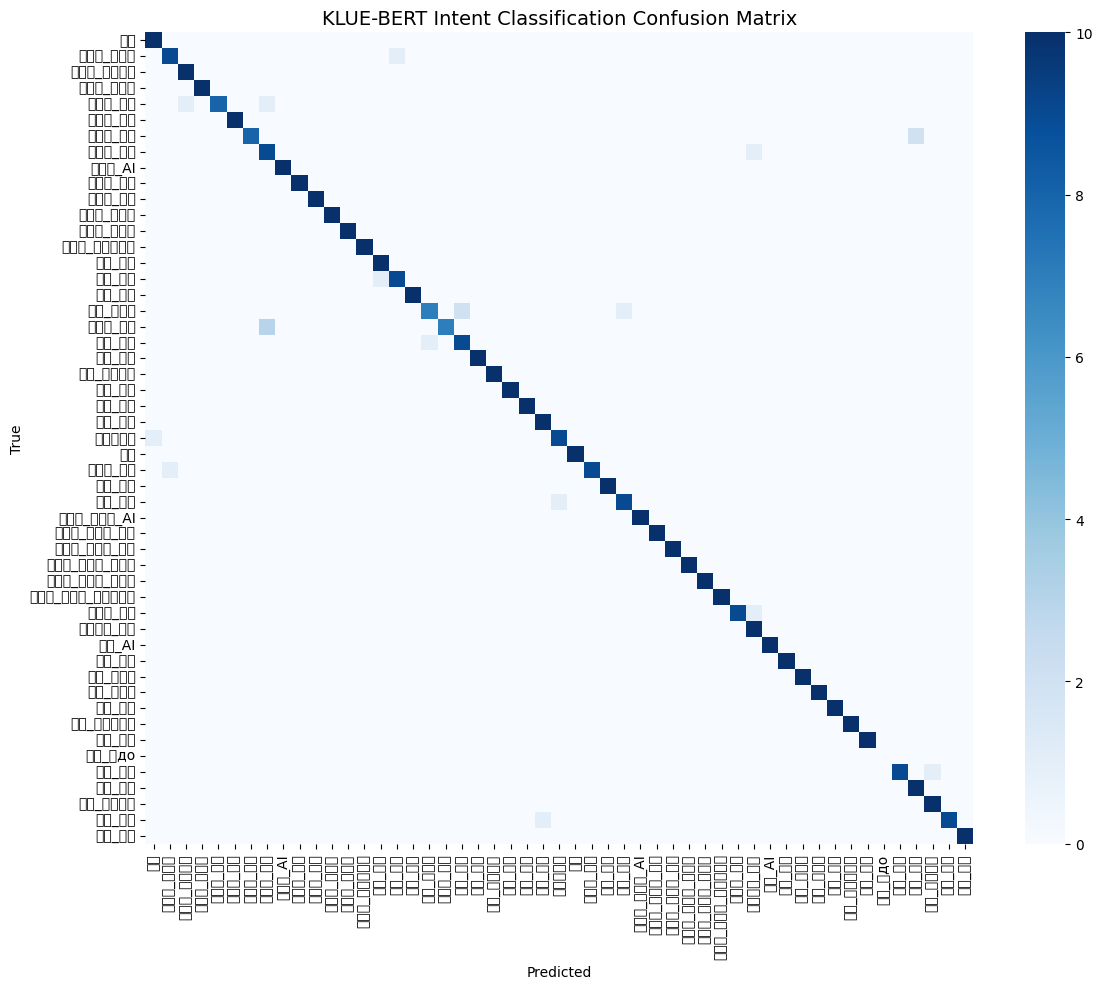

In [2]:
# =========================================================
# train_eval_kluebert_intent.py — 학습 + 평가 + 저장 통합 안정판
# (GPU 사용 / Windows 호환성 / 멀티프로세싱 오류 수정)
# =========================================================
import os
import json
import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from matplotlib import font_manager, rc
import platform  # OS 확인을 위해 추가


# ---------------------------------------------------------
# 0️⃣ 한글 폰트 설정 (Windows/Linux 자동 호환)
# ---------------------------------------------------------
def set_korean_font():
    """OS에 맞춰 한글 폰트 설정"""
    system_name = platform.system()

    if system_name == "Windows":
        font_name = font_manager.FontProperties(
            fname="c:/Windows/Fonts/malgun.ttf"
        ).get_name()
        rc("font", family=font_name)
    elif system_name == "Linux":
        # 사용자가 제공한 경로
        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        if os.path.exists(font_path):
            font_name = font_manager.FontProperties(fname=font_path).get_name()
            rc("font", family=font_name)
        else:
            print(
                "Linux에서 NanumGothic 폰트를 찾을 수 없습니다. 기본 폰트를 사용합니다."
            )
    else:
        print(
            f"{system_name} OS는 폰트 설정을 지원하지 않습니다. 기본 폰트를 사용합니다."
        )

    plt.rcParams["axes.unicode_minus"] = False  # 마이너스 부호 깨짐 방지
    print(f"✅ Font setup for {system_name} complete.")


# ---------------------------------------------------------
# 2️⃣ 데이터 로드 (함수 정의)
# ---------------------------------------------------------
def load_csvs(folder):
    dfs = []
    for f in os.listdir(folder):
        if f.endswith(".csv"):
            try:
                df = pd.read_csv(
                    os.path.join(folder, f), encoding="utf-8", on_bad_lines="skip"
                )
                # "question " (공백 포함) 컬럼명 처리
                if "question " in df.columns:
                    df = df.rename(columns={"question ": "question"})

                if "question" in df.columns and "intent" in df.columns:
                    dfs.append(df[["question", "intent"]])
                else:
                    print(
                        f"Warning: {f} 파일에 'question' 또는 'intent' 컬럼이 없습니다."
                    )

            except Exception as e:
                print(f"Error loading {f}: {e}")

    if not dfs:
        raise ValueError(f"폴더에 유효한 CSV 파일이 없습니다: {folder}")

    return pd.concat(dfs, ignore_index=True)


# ---------------------------------------------------------
# 7️⃣ 지표 정의 (함수 정의)
# ---------------------------------------------------------
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1": f1}


# ---------------------------------------------------------
# ⬇️ 메인 실행 로직 (if __name__ == '__main__': 내부에서 실행)
# ---------------------------------------------------------
def main():

    # 폰트 설정 실행
    set_korean_font()

    # 1️⃣ 경로 설정
    train_dir = "./qi_train"
    test_dir = "./qi_test"
    output_dir = "./kluebert_intent_out"

    # GPU/CPU 장치 설정 확인
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Using device: {device}")

    # ---------------------------------------------------------
    # 2️⃣ 데이터 로드 (실행)
    # ---------------------------------------------------------
    train_df = load_csvs(train_dir).dropna()
    test_df = load_csvs(test_dir).dropna()

    print(f"✅ Train shape: {train_df.shape}, Test shape: {test_df.shape}")

    # ---------------------------------------------------------
    # 3️⃣ 라벨 인코딩
    # ---------------------------------------------------------
    le = LabelEncoder()
    all_labels = sorted(list(set(train_df["intent"]) | set(test_df["intent"])))
    le.fit(all_labels)
    train_df["label"] = le.transform(train_df["intent"])
    test_df["label"] = le.transform(test_df["intent"])

    num_labels = len(le.classes_)
    print(f"✅ {num_labels}개의 라벨 발견: {list(le.classes_)}")

    # ---------------------------------------------------------
    # 4️⃣ Dataset 변환
    # ---------------------------------------------------------
    train_ds = Dataset.from_pandas(train_df)
    test_ds = Dataset.from_pandas(test_df)

    # ---------------------------------------------------------
    # 5️⃣ Tokenizer
    # ---------------------------------------------------------
    model_name = "klue/bert-base"
    tokenizer = BertTokenizerFast.from_pretrained(model_name)

    def preprocess(batch):
        return tokenizer(
            batch["question"], truncation=True, padding="max_length", max_length=32
        )

    train_ds = train_ds.map(preprocess, batched=True)
    test_ds = test_ds.map(preprocess, batched=True)

    # ---------------------------------------------------------
    # 6️⃣ 모델 정의
    # ---------------------------------------------------------
    model = BertForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels
    )
    # model.to(device) # Trainer가 자동으로 처리해줍니다.

    # ---------------------------------------------------------
    # 8️⃣ 학습 설정
    # ---------------------------------------------------------
    training_args = TrainingArguments(
        output_dir=output_dir,
        do_eval=True,
        eval_strategy="epoch",  # ⬅️ evaluation_strategy에서 eval_strategy로 변경
        save_strategy="epoch",
        num_train_epochs=10,          
        learning_rate=3e-5,           
        per_device_train_batch_size=16, 
        per_device_eval_batch_size=16,
        weight_decay=0.01,            
        load_best_model_at_end=True,  
        metric_for_best_model="f1",   
    )

    # ---------------------------------------------------------
    # 9️⃣ Trainer
    # ---------------------------------------------------------
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        processing_class=tokenizer,  # ✅ 'tokenizer' 대신 'processing_class' 사용
        compute_metrics=compute_metrics,
    )

    # ---------------------------------------------------------
    # 🔟 학습 및 평가
    # ---------------------------------------------------------
    print("🚀 KLUE-BERT 모델 학습을 시작합니다...")
    trainer.train()
    eval_result = trainer.evaluate()
    print("\n📊 Evaluation Result:", eval_result)

    # ---------------------------------------------------------
    # 11️⃣ 모델 저장
    # ---------------------------------------------------------
    print(f"✅ 모델 및 토크나이저를 {output_dir}에 저장합니다.")
    model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)

    # 라벨 맵 저장
    label_map = {i: label for i, label in enumerate(le.classes_)}
    with open(os.path.join(output_dir, "label_map.json"), "w", encoding="utf-8") as f:
        json.dump(label_map, f, ensure_ascii=False, indent=2)

    # LabelEncoder 저장 (torch.save 대신 pickle 권장)
    import pickle

    with open(os.path.join(output_dir, "label_encoder.pkl"), "wb") as f:
        pickle.dump(le, f)

    # ---------------------------------------------------------
    # 12️⃣ Confusion Matrix 시각화
    # ---------------------------------------------------------
    print("📊 Confusion Matrix를 생성합니다...")
    predictions = trainer.predict(test_ds)
    y_true = test_df["intent"].tolist()
    y_pred_ids = np.argmax(predictions.predictions, axis=1)
    y_pred = [le.classes_[i] for i in y_pred_ids]

    cm = confusion_matrix(y_true, y_pred, labels=list(le.classes_))

    # 라벨이 너무 많으면(예: 30개 초과) annot=False로 변경
    show_annotations = len(le.classes_) <= 30

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=show_annotations,
        fmt="d",  # 정수로 표현
        cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("KLUE-BERT Intent Classification Confusion Matrix", fontsize=14)
    plt.tight_layout()

    # 그래프를 파일로 저장
    plt.savefig(os.path.join(output_dir, "confusion_matrix.png"))
    print(f"✅ Confusion Matrix가 {output_dir}/confusion_matrix.png 에 저장되었습니다.")

    # (선택) plt.show() # 로컬 환경에서 바로 보려면 주석 해제

    print("\n✅ Training + Evaluation Completed Successfully.")


# ---------------------------------------------------------
# 🚀 스크립트 실행 지점
# (Windows에서 멀티프로세싱 오류를 방지하기 위해 필수)
# ---------------------------------------------------------
if __name__ == "__main__":
    main()


평가

/home/dtlab/miniconda3/envs/kayo2e/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-05 17:16:51.767269: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-05 17:16:51.798032: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-05 17:16:52.793405: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightl

✅ Test shape: (460, 2)


Map: 100%|██████████| 460/460 [00:00<00:00, 42810.42 examples/s]
/tmp/ipykernel_159223/4273033759.py:87: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, args=args, tokenizer=tokenizer)


/home/dtlab/miniconda3/envs/kayo2e/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dtlab/miniconda3/envs/kayo2e/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dtlab/miniconda3/envs/kayo2e/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result


=== 📊 Classification Report ===
               precision    recall  f1-score   support

           감사      1.000     0.900     0.947        10
      동아리_구성원      1.000     0.900     0.947        10
     동아리_네트워크      1.000     0.800     0.889        10
      동아리_분위기      1.000     1.000     1.000        10
       동아리_소개      1.000     0.900     0.947        10
       동아리_역사      1.000     1.000     1.000        10
       동아리_혜택      1.000     0.800     0.889        10
       동아리_활동      0.889     0.800     0.842        10
       면접팁_AI      1.000     1.000     1.000        10
       면접팁_공통      1.000     1.000     1.000        10
       면접팁_기획      1.000     1.000     1.000        10
      면접팁_디자인      1.000     1.000     1.000        10
      면접팁_백엔드      1.000     1.000     1.000        10
    면접팁_프론트엔드      1.000     1.000     1.000        10
        모집_기간      1.000     1.000     1.000        10
        모집_대상      0.909     1.000     0.952        10
        모집_인원      1.000     1.

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
/home/dtlab/miniconda3/envs/kayo2e/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dtlab/miniconda3/envs/kayo2e/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'NanumGothic' not found.
/home/dtlab/miniconda3/envs/kayo2e/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dtlab/miniconda3/envs/kayo2e/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}

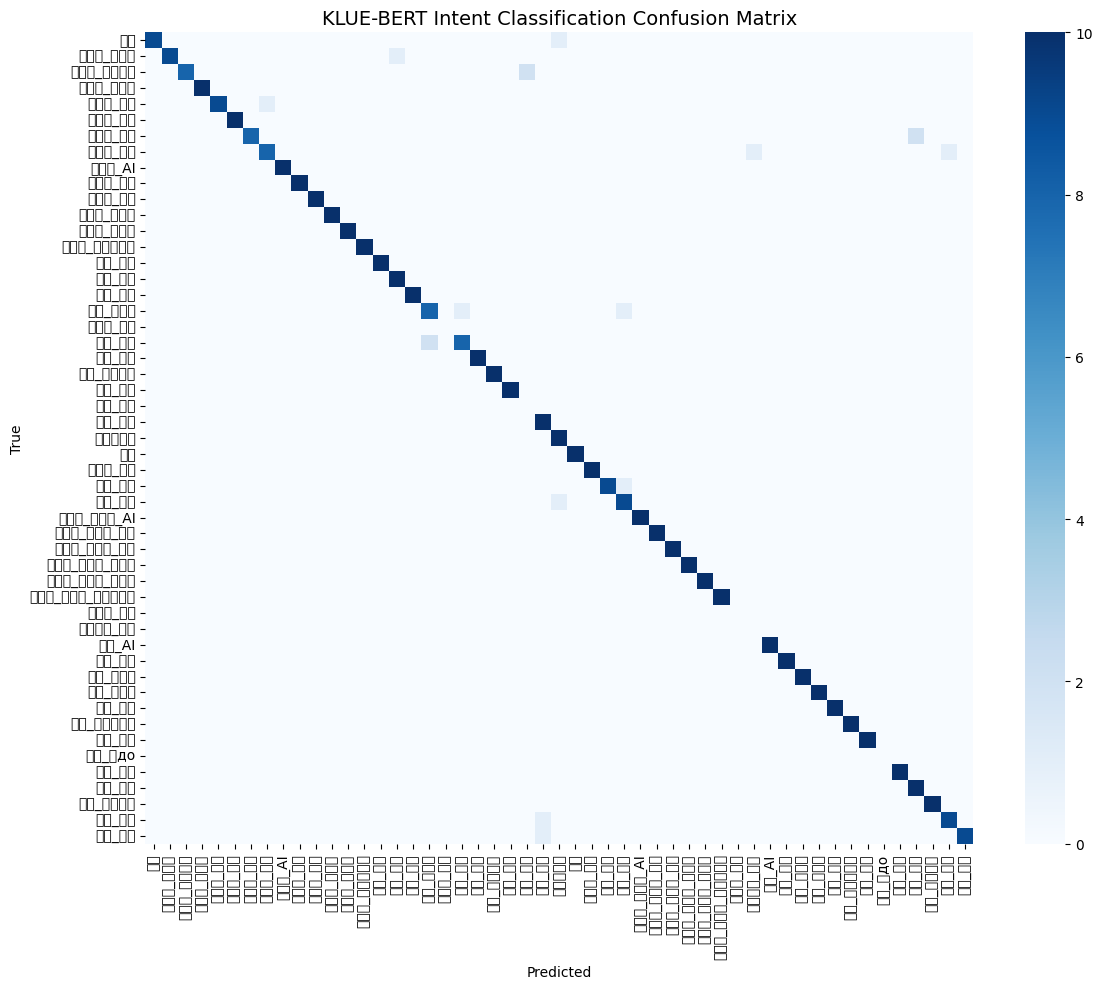


✅ Evaluation completed successfully.


In [ ]:
import os
import json
import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import BertTokenizerFast, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# ---------------------------------------------------------
# 0️⃣ 한글 폰트 세팅 (Ubuntu 기준)
# ---------------------------------------------------------
from matplotlib import font_manager, rc

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if os.path.exists(font_path):
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    rc("font", family=font_name)
    plt.rcParams["axes.unicode_minus"] = False
else:
    print("⚠️ 한글 폰트를 찾지 못했습니다. 기본 폰트로 진행합니다.")

# ---------------------------------------------------------
# 1️⃣ 경로 설정
# ---------------------------------------------------------
model_dir = "./kluebert_intent_out"      # fine-tuned KLUE-BERT
test_dir = "./qi_test"

# ---------------------------------------------------------
# 2️⃣ 테스트 데이터 로드
# ---------------------------------------------------------
test_files = [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.endswith(".csv")]
test_df = pd.concat([pd.read_csv(p, encoding="utf-8", on_bad_lines="skip") for p in test_files],
                    ignore_index=True)

# 필요 컬럼만 남기기
test_df = test_df[["question", "intent"]].dropna()

print(f"✅ Test shape: {test_df.shape}")

# ---------------------------------------------------------
# 3️⃣ 라벨 매핑 로드
# ---------------------------------------------------------
label_map_path = os.path.join(model_dir, "label_map.json")
with open(label_map_path, "r") as f:
    label_map = json.load(f)

# JSON이 dict일 때 key 순서 불일치 방지
idx2label = {int(k): v for k, v in sorted(label_map.items(), key=lambda x: x[0])}
label2idx = {v: k for k, v in idx2label.items()}

# ---------------------------------------------------------
# 4️⃣ 모델 및 토크나이저 로드 (훈련 세팅 그대로)
# ---------------------------------------------------------
tokenizer = BertTokenizerFast.from_pretrained(model_dir)     
model = BertForSequenceClassification.from_pretrained(model_dir)
model.to("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------
# 5️⃣ 전처리
# ---------------------------------------------------------
def preprocess(batch):
    return tokenizer(batch["question"],
                     truncation=True,
                     padding="max_length",
                     max_length=32)   

test_ds = Dataset.from_pandas(test_df)
test_ds = test_ds.map(preprocess, batched=True)

# ---------------------------------------------------------
# 6️⃣ Trainer 세팅 (평가 안정화)
# ---------------------------------------------------------
args = TrainingArguments(
    output_dir="./tmp_eval",
    per_device_eval_batch_size=8,
    dataloader_drop_last=False,
    report_to="none",
    fp16=True if torch.cuda.is_available() else False,
)

trainer = Trainer(model=model, args=args, tokenizer=tokenizer)

# ---------------------------------------------------------
# 7️⃣ 예측 수행
# ---------------------------------------------------------
predictions = trainer.predict(test_ds)

y_true = test_df["intent"].tolist()
y_pred_ids = np.argmax(predictions.predictions, axis=1)
y_pred = [idx2label[i] for i in y_pred_ids]

# ---------------------------------------------------------
# 8️⃣ 성능 리포트
# ---------------------------------------------------------
print("\n=== 📊 Classification Report ===")
print(classification_report(y_true, y_pred, digits=3))

# ---------------------------------------------------------
# 9️⃣ Confusion Matrix 시각화
# ---------------------------------------------------------
plt.figure(figsize=(12, 10))
labels = list(label_map.values())

cm = confusion_matrix(y_true, y_pred, labels=labels)
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("KLUE-BERT Intent Classification Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()

print("\n✅ Evaluation completed successfully.")
